## Data Loading and Initial Inspection

First, let's load the `fraudTest.csv` dataset into a pandas DataFrame and take a look at its first few rows and information.

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df_fraud = pd.read_csv('/content/fraudTest.csv')

# Display the first 5 rows
display(df_fraud.head())

# Display basic information about the DataFrame
display(df_fraud.info())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

None

## Discretization and Binning

Now, let's apply discretization and binning to a continuous numerical column. The `amt` (transaction amount) column seems like a good candidate for this. We will use `pd.cut` to create custom bins and `pd.qcut` for quantile-based bins.

In [ ]:
# Define custom bins for the 'amt' column
bins_amt = [0, 50, 100, 500, 1000, 5000]
labels_amt = ['Low', 'Medium', 'High', 'Very High', 'Extremely High']

# Apply custom binning using pd.cut
df_fraud['amt_binned_custom'] = pd.cut(df_fraud['amt'], bins=bins_amt, labels=labels_amt, right=True)

print("Value counts for custom binned amounts:")
display(df_fraud['amt_binned_custom'].value_counts())

# Apply quantile-based binning using pd.qcut (e.g., into 4 quartiles)
df_fraud['amt_binned_quartile'] = pd.qcut(df_fraud['amt'], q=4, duplicates='drop')

print("\nValue counts for quartile binned amounts:")
display(df_fraud['amt_binned_quartile'].value_counts())

display(df_fraud[['amt', 'amt_binned_custom', 'amt_binned_quartile']].head())

Value counts for custom binned amounts:


,count
amt_binned_custom,
Low,288930
Medium,166804
High,93907
Very High,4495
Extremely High,1524



Value counts for quartile binned amounts:


,count
amt_binned_quartile,
"(0.999, 9.63]",139027
"(47.29, 83.01]",138952
"(83.01, 22768.11]",138904
"(9.63, 47.29]",138836


,amt,amt_binned_custom,amt_binned_quartile
0,2.86,Low,"(0.999, 9.63]"
1,29.84,Low,"(9.63, 47.29]"
2,41.28,Low,"(9.63, 47.29]"
3,60.05,Medium,"(47.29, 83.01]"
4,3.19,Low,"(0.999, 9.63]"


## Outlier Detection and Filtering

Outliers can significantly impact statistical analysis. Let's detect and filter outliers in the `amt` column. We will identify transactions with amounts exceeding a certain threshold (e.g., a very high value, like transactions over $5000).

In [ ]:
# Define an outlier threshold for 'amt'
outlier_threshold = 5000

# Identify outliers
outliers_amt = df_fraud[df_fraud['amt'] > outlier_threshold]

print(f"Transactions identified as outliers (amount > ${outlier_threshold}):")
display(outliers_amt.head())

print(f"Number of outliers: {len(outliers_amt)}")

# Filter out outliers (create a new DataFrame without them)
df_fraud_filtered = df_fraud[df_fraud['amt'] <= outlier_threshold]

print(f"\nOriginal DataFrame shape: {df_fraud.shape}")
print(f"DataFrame shape after filtering outliers: {df_fraud_filtered.shape}")
display(df_fraud_filtered.head())

Transactions identified as outliers (amount > $5000):


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_binned_custom,amt_binned_quartile
13466,13466,2020-06-25 19:43:13,4378993458389626,fraud_Fritsch LLC,travel,6600.44,Travis,Hayes,M,1561 Chase Grove,...,3807,Surgeon,1999-10-25,6ad730c17f10beeb66462e8e0bdb8651,1372189393,43.741878,-71.699656,0,NaN,"(83.01, 22768.11]"
35542,35542,2020-07-03 18:13:00,4797297220948468262,"fraud_Hagenes, Hermann and Stroman",travel,13149.15,Erica,Briggs,F,3310 Davidson Spurs Apt. 107,...,1228,Counsellor,1991-03-13,3a9d71cce25e35776395ce67aefff16f,1372875180,39.435860,-87.298161,0,NaN,"(83.01, 22768.11]"
35983,35983,2020-07-03 21:57:20,676372984911,"fraud_Hahn, Douglas and Schowalter",travel,6297.01,Vicki,Mendoza,F,3645 Atkins Island Apt. 238,...,242,Tourism officer,1987-07-18,23697553e774de088f3021d926769196,1372888640,39.908197,-97.909893,0,NaN,"(83.01, 22768.11]"
43802,43802,2020-07-06 12:54:50,676102124465,"fraud_Eichmann, Hayes and Treutel",travel,6181.12,Natasha,Mclaughlin,F,8699 Lindsay Ford Apt. 486,...,94014,Airline pilot,1985-08-21,9d21b68cd5340c9571447236e85930e0,1373115290,39.396649,-123.046094,0,NaN,"(83.01, 22768.11]"
48749,48749,2020-07-07 17:05:38,4969856774088583,fraud_Jerde-Hermann,travel,8021.63,Jacqueline,Prince,F,27823 Andrew Underpass Suite 948,...,137067,Advertising account planner,1951-12-04,af4195efd82f60701b3759a199095b1a,1373216738,30.574686,-91.134536,0,NaN,"(83.01, 22768.11]"


Number of outliers: 59

Original DataFrame shape: (555719, 25)
DataFrame shape after filtering outliers: (555660, 25)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,amt_binned_custom,amt_binned_quartile
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,Low,"(0.999, 9.63]"
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,Low,"(9.63, 47.29]"
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,Low,"(9.63, 47.29]"
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,Medium,"(47.29, 83.01]"
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,Low,"(0.999, 9.63]"


## Feature Scaling and Normalization

Feature scaling is crucial for many machine learning algorithms. We will demonstrate `MinMaxScaler`, `StandardScaler`, and `RobustScaler` on selected numerical columns like `amt`, `city_pop`, and `is_fraud` (although `is_fraud` is binary, scaling it might not be standard but is used here for demonstration of numerical columns).

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Select numerical columns for scaling demonstration
# Let's consider 'amt', 'city_pop', 'unix_time' and 'merch_lat' as examples
numerical_cols = ['amt', 'city_pop', 'unix_time', 'merch_lat']

# Create a copy of the DataFrame for scaling to avoid modifying the original 'df_fraud'
df_scaling = df_fraud[numerical_cols].copy()

print("Original Data for Scaling:")
display(df_scaling.head())

# 1. Min-Max Scaling (Normalization)
min_max_scaler = MinMaxScaler()
df_scaling_min_max = pd.DataFrame(
    min_max_scaler.fit_transform(df_scaling),
    columns=numerical_cols
)
print("\nMin-Max Scaled Data:")
display(df_scaling_min_max.head())

# 2. Z-score Standardization
standard_scaler = StandardScaler()
df_scaling_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_scaling),
    columns=numerical_cols
)
print("\nStandardized Data:")
display(df_scaling_standard.head())

# 3. Robust Scaling (less affected by outliers)
robust_scaler = RobustScaler()
df_scaling_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_scaling),
    columns=numerical_cols
)
print("\nRobust Scaled Data:")
display(df_scaling_robust.head())

Original Data for Scaling:


,amt,city_pop,unix_time,merch_lat
0,2.86,333497,1371816865,33.986391
1,29.84,302,1371816873,39.450498
2,41.28,34496,1371816893,40.495810
3,60.05,54767,1371816915,28.812398
4,3.19,1126,1371816917,44.959148



Min-Max Scaled Data:


,amt,city_pop,unix_time,merch_lat
0,0.000082,0.114727,0.000000e+00,0.313922
1,0.001267,0.000096,4.785402e-07,0.428589
2,0.001769,0.011860,1.674891e-06,0.450526
3,0.002594,0.018834,2.990876e-06,0.205343
4,0.000096,0.000379,3.110511e-06,0.544191



Standardized Data:


,amt,city_pop,unix_time,merch_lat
0,-0.424463,0.816521,-1.703871,-0.894145
1,-0.252337,-0.292685,-1.703869,0.178126
2,-0.179353,-0.178853,-1.703865,0.383257
3,-0.059605,-0.111371,-1.703861,-1.909485
4,-0.422358,-0.289942,-1.703861,1.259139



Robust Scaled Data:


,amt,city_pop,unix_time,merch_lat
0,-0.605478,17.477249,-0.909209,-0.748758
1,-0.237803,-0.111170,-0.909208,0.010266
2,-0.081902,1.693834,-0.909206,0.155471
3,0.173889,2.763883,-0.909204,-1.467481
4,-0.600981,-0.067673,-0.909204,0.775477


## Visualization: Distribution of 'amt' before and after Outlier Filtering

Let's visualize the distribution of the `amt` column from the original DataFrame and the filtered DataFrame to observe the effect of outlier removal.

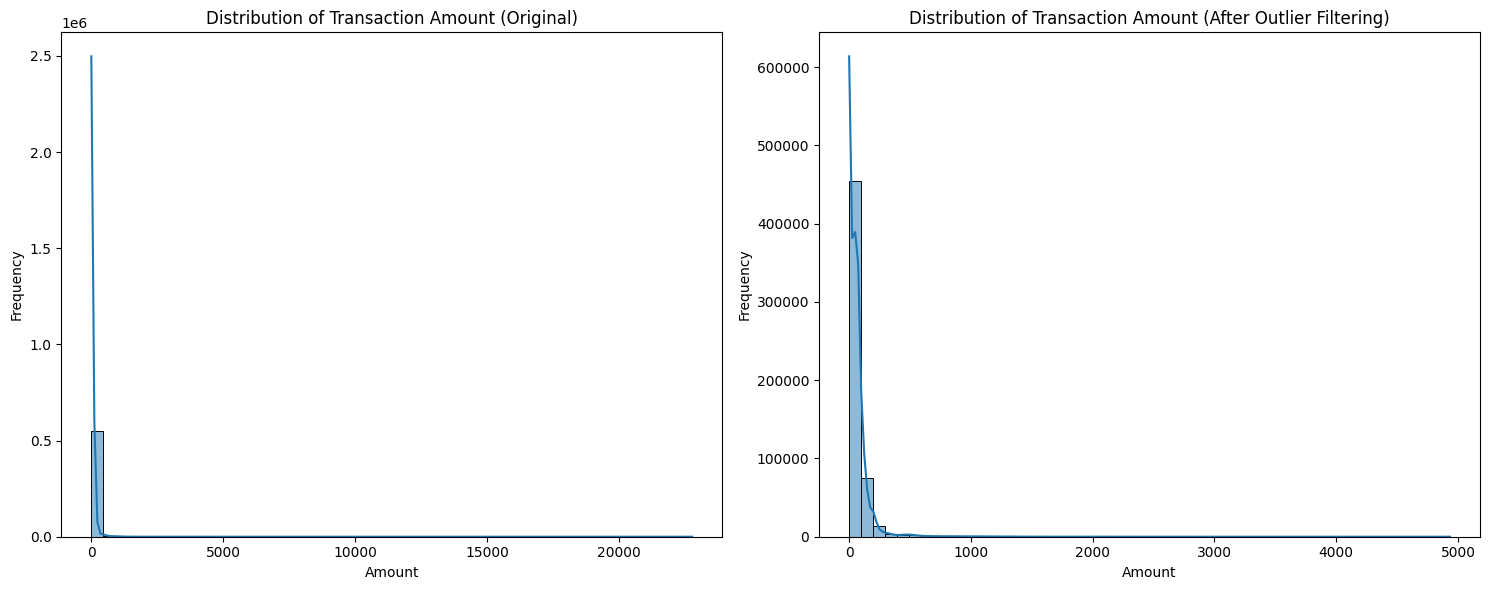

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Plotting distribution of original 'amt'
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df_fraud['amt'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount (Original)')
plt.xlabel('Amount')
plt.ylabel('Frequency')

# Plotting distribution of filtered 'amt'
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(df_fraud_filtered['amt'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount (After Outlier Filtering)')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Visualization: Frequency of Transaction Categories

Let's visualize the frequency of each transaction category using a bar chart to understand the most common types of transactions.

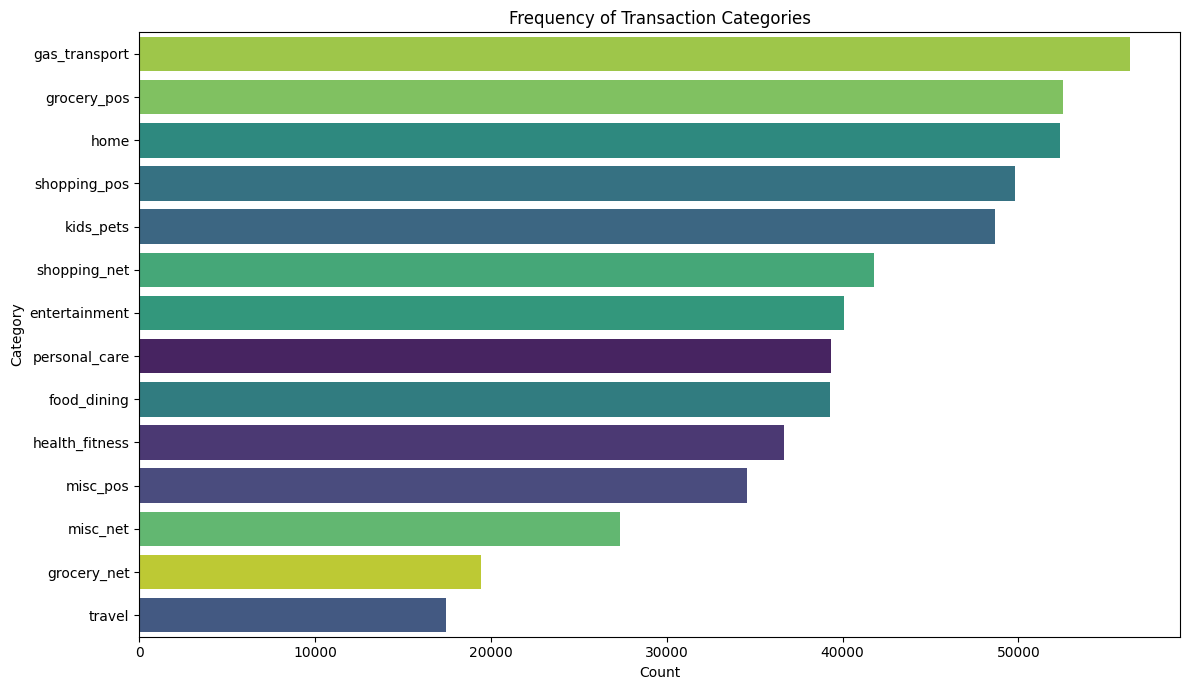

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df_fraud, y='category', order=df_fraud['category'].value_counts().index, palette='viridis', hue='category', legend=False)
plt.title('Frequency of Transaction Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## Fraud Percentage by Category

Let's calculate the percentage of fraudulent transactions for each `category` to identify which categories are more prone to fraud.

In [ ]:
# Group by 'category' and calculate total transactions and fraudulent transactions
fraud_by_category = df_fraud.groupby('category').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_transactions=('is_fraud', lambda x: (x == 1).sum())
).reset_index()

# Calculate the percentage of fraud
fraud_by_category['percentage_fraud'] = (fraud_by_category['fraud_transactions'] / fraud_by_category['total_transactions']) * 100

# Sort by percentage_fraud in descending order
fraud_by_category = fraud_by_category.sort_values(by='percentage_fraud', ascending=False)

print("Percentage of Fraud Cases for Each Category:")
display(fraud_by_category)

Percentage of Fraud Cases for Each Category:


,category,total_transactions,fraud_transactions,percentage_fraud
11,shopping_net,41779,506,1.211135
8,misc_net,27367,267,0.975628
4,grocery_pos,52553,485,0.922878
12,shopping_pos,49791,213,0.427788
2,gas_transport,56370,154,0.273195
13,travel,17449,40,0.229239
3,grocery_net,19426,41,0.211057
9,misc_pos,34574,72,0.208249
10,personal_care,39327,70,0.177995
0,entertainment,40104,59,0.147117


## Category with Highest Fraud Risk

Let's identify the category that has the highest percentage of fraudulent transactions from the `fraud_by_category` table we just created.

In [ ]:
# The fraud_by_category DataFrame is already sorted by 'percentage_fraud' in descending order
# So, the first row will give us the category with the highest fraud risk.
highest_fraud_risk_category = fraud_by_category.iloc[0]

print("Category with the highest fraud risk:")
display(highest_fraud_risk_category)

Category with the highest fraud risk:


,11
category,shopping_net
total_transactions,41779
fraud_transactions,506
percentage_fraud,1.211135


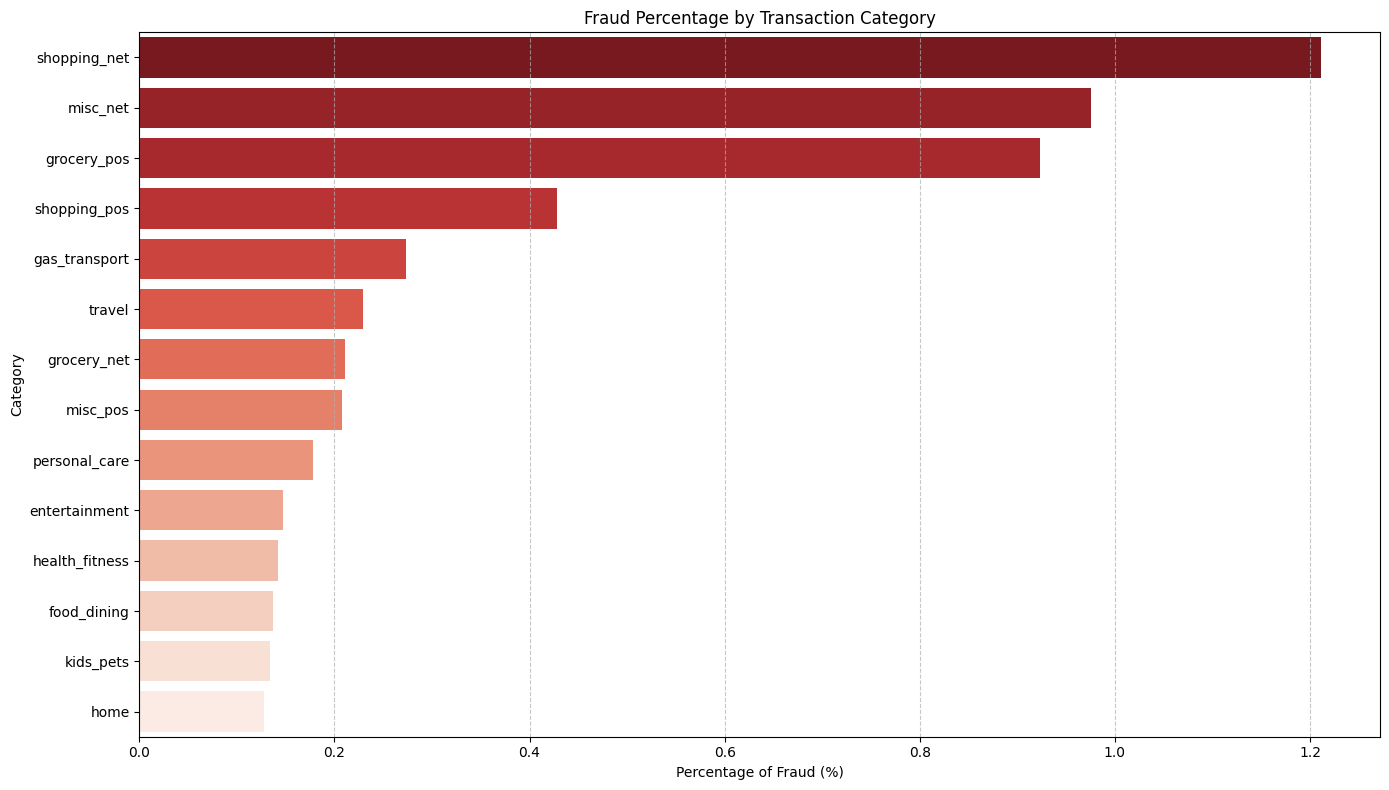

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='percentage_fraud', y='category', data=fraud_by_category, palette='Reds_r', hue='category', legend=False)
plt.title('Fraud Percentage by Transaction Category')
plt.xlabel('Percentage of Fraud (%)')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Statistical Test: Chi-squared Test for Independence of Category and Fraud

To statistically compare fraud rates across categories, we can use a Chi-squared test of independence. This test will determine if there is a significant association between the `category` of a transaction and whether it is `is_fraud`.

In [ ]:
from scipy.stats import chi2_contingency

# Create a contingency table of 'category' and 'is_fraud'
contingency_table = pd.crosstab(df_fraud['category'], df_fraud['is_fraud'])

print("Contingency Table (Category vs. Is Fraud):")
display(contingency_table)

# Perform the Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-squared Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nBased on the Chi-squared test, there is a statistically significant association between transaction category and the occurrence of fraud (p < 0.05).")
else:
    print("\nBased on the Chi-squared test, there is no statistically significant association between transaction category and the occurrence of fraud (p >= 0.05).")

Contingency Table (Category vs. Is Fraud):


is_fraud,0,1
category,,
entertainment,40045,59
food_dining,39214,54
gas_transport,56216,154
grocery_net,19385,41
grocery_pos,52068,485
health_fitness,36622,52
home,52278,67
kids_pets,48627,65
misc_net,27100,267



Chi-squared Statistic: 1852.24
P-value: 0.0000
Degrees of Freedom: 13

Based on the Chi-squared test, there is a statistically significant association between transaction category and the occurrence of fraud (p < 0.05).


## Visualization: Distribution of Transaction Amounts for Top 3 High-Risk Categories

Let's visualize the distribution of transaction amounts (`amt`) for the top 3 high-risk categories using box plots. This will help us understand if there are differences in the transaction amount distributions that contribute to their higher fraud rates.

In [ ]:







from scipy.stats import chi2_contingency

p_values_by_category = {}

for category in df_fraud['category'].unique():
    # Create a 2x2 contingency table for the current category vs. all other categories
    # [Current Category, Not Current Category]
    # [Is Fraud, Is Not Fraud]

    # Current category, is fraud
    cat_fraud = df_fraud[(df_fraud['category'] == category) & (df_fraud['is_fraud'] == 1)].shape[0]
    # Current category, is not fraud
    cat_non_fraud = df_fraud[(df_fraud['category'] == category) & (df_fraud['is_fraud'] == 0)].shape[0]
    # Other categories, is fraud
    other_fraud = df_fraud[(df_fraud['category'] != category) & (df_fraud['is_fraud'] == 1)].shape[0]
    # Other categories, is not fraud
    other_non_fraud = df_fraud[(df_fraud['category'] != category) & (df_fraud['is_fraud'] == 0)].shape[0]

    contingency_table_cat = np.array([[
        cat_fraud,
        cat_non_fraud
    ], [
        other_fraud,
        other_non_fraud
    ]])

    # Perform Chi-squared test
    # Check if the table is valid for chi2_contingency (no zero rows/cols, at least one value)
    if np.sum(contingency_table_cat) > 0 and np.all(np.sum(contingency_table_cat, axis=0) > 0) and np.all(np.sum(contingency_table_cat, axis=1) > 0):
        _, p_value_cat, _, _ = chi2_contingency(contingency_table_cat)
        p_values_by_category[category] = p_value_cat
    else:
        p_values_by_category[category] = np.nan # Not enough data for a valid test

# Display the p-values for each category
p_values_df = pd.DataFrame(p_values_by_category.items(), columns=['category', 'p_value'])
p_values_df = p_values_df.sort_values(by='p_value')

print("P-values for each category (Chi-squared test comparing category vs. others for fraud):")
display(p_values_df)

P-values for each category (Chi-squared test comparing category vs. others for fraud):


,category,p_value
9,shopping_net,1.750834e-175
11,grocery_pos,2.685872e-96
10,misc_net,3.344682e-58
7,home,2.175075e-23
4,kids_pets,7.347573e-21
6,food_dining,2.513915e-16
8,entertainment,1.624610e-15
1,health_fitness,8.487612e-15
0,personal_care,6.965661e-12
2,misc_pos,4.790041e-08


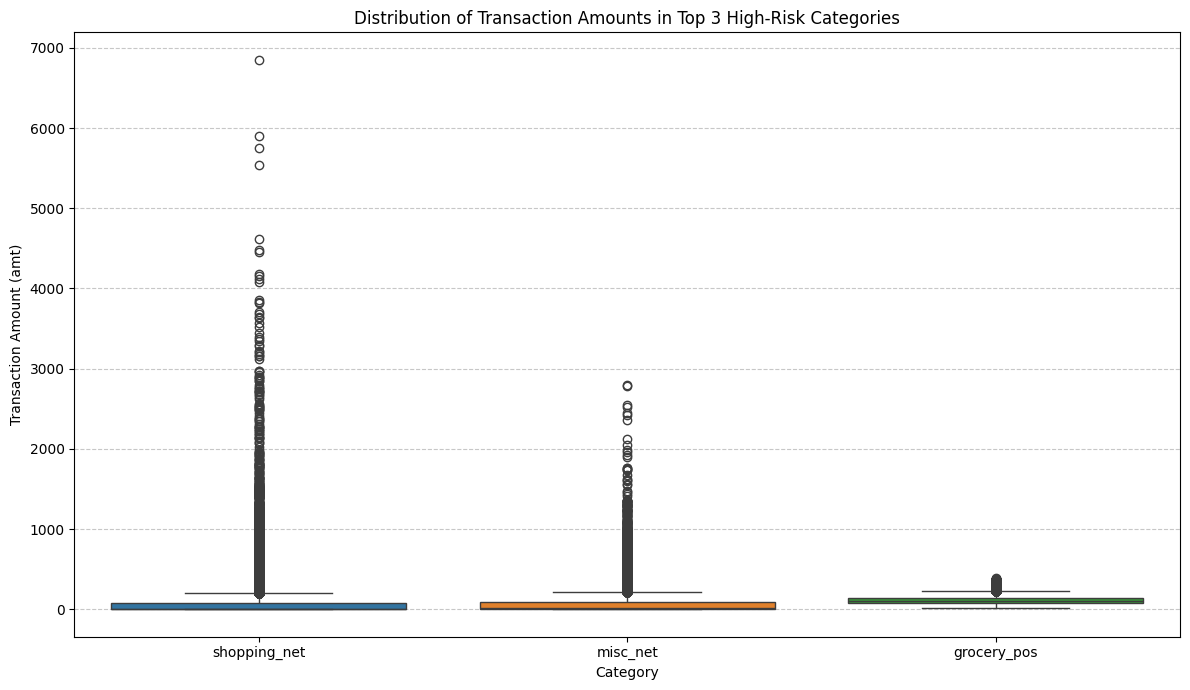

In [ ]:
# Get the top 3 high-risk categories (from the sorted fraud_by_category DataFrame)
top_3_categories = fraud_by_category.head(3)['category'].tolist()

# Filter the original DataFrame for these categories
df_top_3_amt_categories = df_fraud[df_fraud['category'].isin(top_3_categories)]

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_top_3_amt_categories, x='category', y='amt', hue='category', legend=False)
plt.title('Distribution of Transaction Amounts in Top 3 High-Risk Categories')
plt.xlabel('Category')
plt.ylabel('Transaction Amount (amt)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Statistical Test: Independent Samples T-test for Transaction Amounts (Fraud vs. Non-Fraud)

To compare the transaction amounts (`amt`) between fraudulent and non-fraudulent transactions, we can perform an independent samples t-test. This test assesses whether the means of two independent groups are significantly different.

In [ ]:
from scipy.stats import ttest_ind

# Separate transaction amounts for fraudulent and non-fraudulent transactions
amt_fraud = df_fraud[df_fraud['is_fraud'] == 1]['amt']
amt_non_fraud = df_fraud[df_fraud['is_fraud'] == 0]['amt']

print(f"Mean amount for fraudulent transactions: ${amt_fraud.mean():.2f}")
print(f"Mean amount for non-fraudulent transactions: ${amt_non_fraud.mean():.2f}")

# Perform independent samples t-test
t_statistic, p_value = ttest_ind(amt_fraud, amt_non_fraud, equal_var=False) # Assuming unequal variances

print(f"\nIndependent Samples T-test Results:")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("\nBased on the t-test, there is a statistically significant difference in the mean transaction amounts between fraudulent and non-fraudulent transactions (p < 0.05).")
else:
    print("\nBased on the t-test, there is no statistically significant difference in the mean transaction amounts between fraudulent and non-fraudulent transactions (p >= 0.05).")

Mean amount for fraudulent transactions: $528.36
Mean amount for non-fraudulent transactions: $67.61

Independent Samples T-test Results:
T-statistic: 54.32
P-value: 0.0000

Based on the t-test, there is a statistically significant difference in the mean transaction amounts between fraudulent and non-fraudulent transactions (p < 0.05).


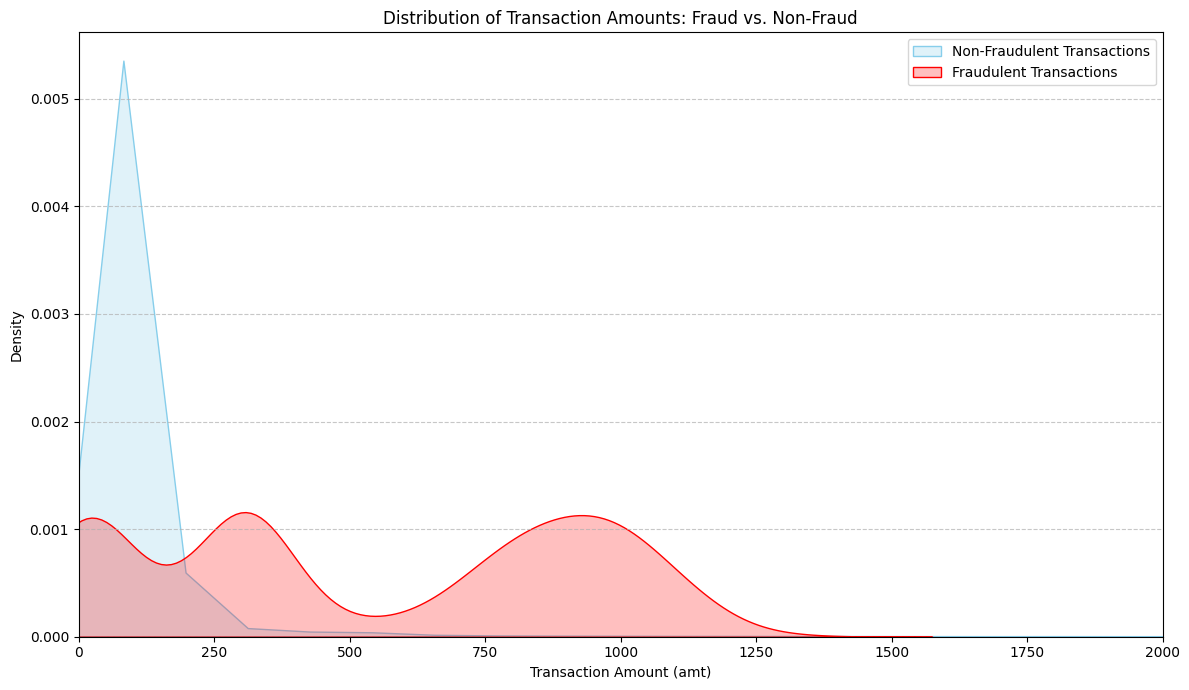

In [ ]:
plt.figure(figsize=(12, 7))
sns.kdeplot(amt_non_fraud, label='Non-Fraudulent Transactions', fill=True, color='skyblue')
sns.kdeplot(amt_fraud, label='Fraudulent Transactions', fill=True, color='red')
plt.title('Distribution of Transaction Amounts: Fraud vs. Non-Fraud')
plt.xlabel('Transaction Amount (amt)')
plt.ylabel('Density')
plt.xlim(0, 2000) # Limit x-axis for better visibility of the main distributions
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

# Filter the DataFrame for only the top 3 high-risk categories
df_top_3_fraud_categories = df_fraud[df_fraud['category'].isin(top_3_categories)]

# Create a contingency table for these top categories and 'is_fraud'
contingency_table_top_3 = pd.crosstab(df_top_3_fraud_categories['category'], df_top_3_fraud_categories['is_fraud'])

print("Contingency Table (Top 3 Categories vs. Is Fraud):")
display(contingency_table_top_3)

# Perform the Chi-squared test
chi2_top_3, p_value_top_3, dof_top_3, expected_top_3 = chi2_contingency(contingency_table_top_3)

print(f"\nChi-squared Statistic for Top 3 Categories: {chi2_top_3:.2f}")
print(f"P-value for Top 3 Categories: {p_value_top_3:.4f}")
print(f"Degrees of Freedom for Top 3 Categories: {dof_top_3}")

# Interpret the results
alpha = 0.05
if p_value_top_3 < alpha:
    print("\nBased on the Chi-squared test for the top 3 categories, there is a statistically significant association between these specific transaction categories and the occurrence of fraud (p < 0.05).")
else:
    print("\nBased on the Chi-squared test for the top 3 categories, there is no statistically significant association between these specific transaction categories and the occurrence of fraud (p >= 0.05).")

Contingency Table (Top 3 Categories vs. Is Fraud):


is_fraud,0,1
category,,
grocery_pos,52068,485
misc_net,27100,267
shopping_net,41273,506



Chi-squared Statistic for Top 3 Categories: 20.07
P-value for Top 3 Categories: 0.0000
Degrees of Freedom for Top 3 Categories: 2

Based on the Chi-squared test for the top 3 categories, there is a statistically significant association between these specific transaction categories and the occurrence of fraud (p < 0.05).


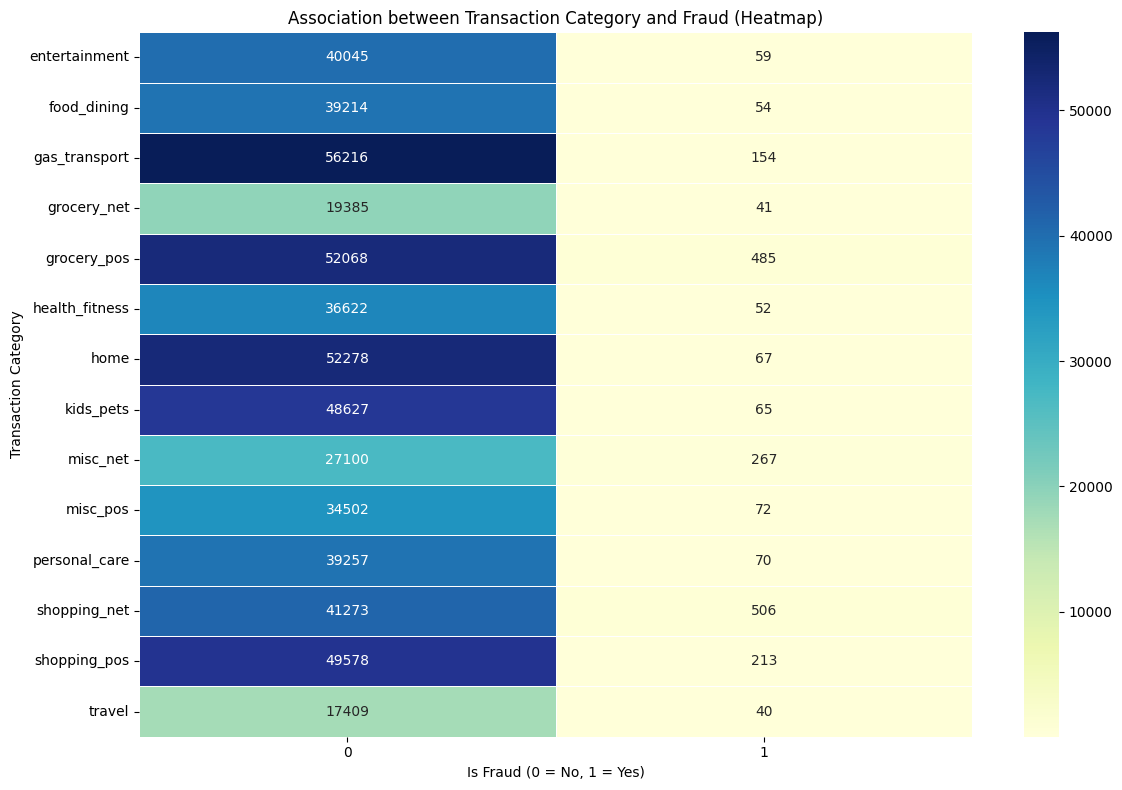

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Association between Transaction Category and Fraud (Heatmap)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Transaction Category')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the correlation between 'amt' and 'is_fraud'
correlation = df_fraud['amt'].corr(df_fraud['is_fraud'])

print(f"Correlation between Transaction Amount and Fraud Status: {correlation:.4f}")

Correlation between Transaction Amount and Fraud Status: 0.1823
